# 04 — Negative Coordinate Generation

Sample "did not fail" locations to pair with the ACCIMT landslide inventory.

Strategy decisions (Stage 1 of the brief):

| Decision | Choice | Why |
|---|---|---|
| Sampling region | 1–4 km annulus around landslide polygons | Same geology, slope regime and Ditwah rainfall. Island-wide negatives would let the model win by recognising "highlands vs coastal plain" — a shortcut that collapses on new data. |
| Minimum distance | 1000 m from any polygon | 640 m patch + margin, so no negative patch clips a mapped landslide. |
| Maximum distance | 4000 m | Beyond this, terrain and rainfall context start to diverge. |
| Separation | 400 m between negatives | Prevents near-duplicate patches straddling the train/test split. |
| Ratio | 1:1 with positives | Balanced classes; real-world prevalence is discussed in evaluation. |
| Slope matching | optional second pass | Forces the model past "steep = landslide". |

Output: data/coordinates/negative_coordinates.csv — same schema as
landslide_coordinates.csv, so the acquisition notebook runs unchanged.

> Inventory: Arthur C. Clarke Institute for Modern Technologies (ACCIMT),
> Sri Lanka. Academic use only.

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyogrio import list_layers
from scipy.spatial import cKDTree
from shapely.geometry import Point
from shapely.ops import unary_union

PROJECT_DIR = Path("..").resolve()
COORD_DIR   = PROJECT_DIR / "data" / "coordinates"
KML_DIR     = PROJECT_DIR / "data" / "raw" / "kml"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
for d in (COORD_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

DST_CRS = "EPSG:32644"           # UTM 44N — metric, correct for Sri Lanka

PATCH_SIZE_M   = 640             # must match the acquisition notebook
MIN_SEPARATION = 640             # no two patches may overlap, either class
MIN_DIST_M     = 1000            # negatives: min distance to any landslide
MAX_DIST_M     = 4000            # negatives: outer edge of the ring
NEG_RATIO      = 1.5
SEED           = 42

rng = np.random.default_rng(SEED)

half_diag = (PATCH_SIZE_M / 2) * np.sqrt(2)
print(f"patch {PATCH_SIZE_M} m  (half-diagonal {half_diag:.0f} m)")
print(f"separation {MIN_SEPARATION} m | ring {MIN_DIST_M}-{MAX_DIST_M} m")
assert half_diag < MIN_DIST_M, "Patch corner could overlap a landslide"

patch 640 m  (half-diagonal 453 m)
separation 640 m | ring 1000-4000 m


In [48]:
src = sorted(KML_DIR.glob("*.km[lz]"))
assert src, f"No .kml/.kmz found in {KML_DIR}"
src = src[0]
print("reading:", src.name)

try:
    layers = [l[0] for l in list_layers(str(src))]
except Exception:
    layers = [l[0] for l in list_layers(f"/vsizip/{src.as_posix()}")]
    src = Path(f"/vsizip/{src.as_posix()}")
print(f"{len(layers)} layer(s): {layers[:5]}")

frames = []
for layer in layers:
    try:
        g = gpd.read_file(str(src), layer=layer)
        if len(g):
            frames.append(g)
    except Exception as exc:
        print(f"  skipped {layer}: {exc}")

polys = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs="EPSG:4326")
polys = polys[polys.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
polys["geometry"] = polys.geometry.force_2d()
polys = polys.explode(index_parts=False, ignore_index=True).to_crs(DST_CRS)
polys["geometry"] = polys.geometry.buffer(0)
polys = polys[polys.geometry.is_valid & ~polys.geometry.is_empty].reset_index(drop=True)
polys["area_m2"] = polys.geometry.area

print(f"{len(polys)} polygons | {polys.area_m2.sum()/1e6:.1f} km² mapped")

reading: Lanslides_Ditwa_2025.kmz
1 layer(s): ['Lanslides_Ditwa_2025']
4226 polygons | 31.3 km² mapped


In [49]:
pos_raw = pd.read_csv(COORD_DIR / "landslide_coordinates.csv")
print(f"{len(pos_raw)} raw positive coordinates")
print("columns:", list(pos_raw.columns))

p = gpd.GeoDataFrame(pos_raw, geometry=gpd.points_from_xy(
    pos_raw.longitude, pos_raw.latitude), crs="EPSG:4326").to_crs(DST_CRS)
p["utm_x"], p["utm_y"] = p.geometry.x, p.geometry.y

xy = np.c_[p.utm_x, p.utm_y]
nn = cKDTree(xy).query(xy, k=2)[0][:, 1]
print(f"\nBEFORE thinning:")
print(f"  nearest neighbour: min {nn.min():.0f} m, median {np.median(nn):.0f} m")
print(f"  overlapping (<{MIN_SEPARATION} m): {(nn < MIN_SEPARATION).sum()} "
      f"({(nn < MIN_SEPARATION).mean()*100:.1f}%)")

4225 raw positive coordinates
columns: ['landslide_id', 'longitude', 'latitude', 'area_m2', 'perimeter_m', 'min_lon', 'min_lat', 'max_lon', 'max_lat']

BEFORE thinning:
  nearest neighbour: min 0 m, median 188 m
  overlapping (<640 m): 3696 (87.5%)


In [50]:
# Attach polygon area so the largest slide in each cluster is kept
if "area_m2" not in p.columns:
    joined = gpd.sjoin_nearest(
        p[["geometry"]], polys[["geometry", "area_m2"]],
        how="left", max_distance=200)
    p["area_m2"] = joined.groupby(level=0).area_m2.max().reindex(p.index).fillna(0)

order = p.sort_values("area_m2", ascending=False).index

kept_xy, kept_idx = [], []
for i in order:
    x, y = p.at[i, "utm_x"], p.at[i, "utm_y"]
    if kept_xy:
        a = np.asarray(kept_xy)
        if np.min(np.hypot(a[:, 0] - x, a[:, 1] - y)) < MIN_SEPARATION:
            continue
    kept_xy.append([x, y])
    kept_idx.append(i)

pos = (p.loc[kept_idx]
        .drop(columns=["geometry"])
        .sort_index()
        .reset_index(drop=True))

xy = np.c_[pos.utm_x, pos.utm_y]
nn_after = cKDTree(xy).query(xy, k=2)[0][:, 1]

print(f"{len(pos_raw)} -> {len(pos)} positives "
      f"({len(pos)/len(pos_raw)*100:.0f}% retained)")
print(f"AFTER thinning:")
print(f"  nearest neighbour: min {nn_after.min():.0f} m, "
      f"median {np.median(nn_after):.0f} m")
assert nn_after.min() >= MIN_SEPARATION * 0.99, "thinning failed"

pos.to_csv(COORD_DIR / "landslide_coordinates_thinned.csv", index=False)
print("written: landslide_coordinates_thinned.csv")

4225 -> 1512 positives (36% retained)
AFTER thinning:
  nearest neighbour: min 640 m, median 853 m
written: landslide_coordinates_thinned.csv


In [51]:
all_slides = unary_union(polys.geometry.values)

inner  = all_slides.buffer(MIN_DIST_M)
outer  = all_slides.buffer(MAX_DIST_M)
region = outer.difference(inner)

n_target = int(len(pos) * NEG_RATIO)
capacity = region.area / (MIN_SEPARATION ** 2)

print(f"exclusion zone : {inner.area/1e6:,.0f} km²")
print(f"sampling ring  : {region.area/1e6:,.0f} km²")
print(f"target         : {n_target} negatives")
print(f"capacity       : ~{capacity:,.0f} points")
assert capacity > n_target * 2, "Ring too small — raise MAX_DIST_M"

exclusion zone : 3,253 km²
sampling ring  : 5,540 km²
target         : 1512 negatives
capacity       : ~13,525 points


In [53]:
minx, miny, maxx, maxy = region.bounds
pts, attempts = [], 0

while len(pts) < n_target and attempts < 400:
    attempts += 1
    xs = rng.uniform(minx, maxx, 5000)
    ys = rng.uniform(miny, maxy, 5000)
    for x, y in zip(xs, ys):
        if not region.contains(Point(x, y)):
            continue
        if pts:
            a = np.asarray(pts)
            if np.min(np.hypot(a[:, 0] - x, a[:, 1] - y)) < MIN_SEPARATION:
                continue
        pts.append([x, y])
        if len(pts) >= n_target:
            break
    if attempts % 20 == 0:
        print(f"  batch {attempts}: {len(pts)}/{n_target}")

pts = np.asarray(pts)
print(f"\n{len(pts)} negatives sampled in {attempts} batches")


1512 negatives sampled in 2 batches


In [54]:
neg_g = gpd.GeoDataFrame(
    {"landslide_id": [f"NEG{i:05d}" for i in range(len(pts))]},
    geometry=gpd.points_from_xy(pts[:, 0], pts[:, 1]), crs=DST_CRS)

d_slide = neg_g.geometry.distance(all_slides)
print(f"distance to nearest landslide: min {d_slide.min():.0f} m, "
      f"median {d_slide.median():.0f} m, max {d_slide.max():.0f} m")
assert d_slide.min() >= MIN_DIST_M * 0.99

nn_neg = cKDTree(pts).query(pts, k=2)[0][:, 1]
print(f"negative nearest neighbour: min {nn_neg.min():.0f} m")
assert nn_neg.min() >= MIN_SEPARATION * 0.99

print("\nall checks passed")

distance to nearest landslide: min 1001 m, median 2288 m, max 3998 m
negative nearest neighbour: min 640 m

all checks passed


In [55]:
wgs = neg_g.to_crs("EPSG:4326")
out = pd.DataFrame({
    "landslide_id": neg_g.landslide_id.values,
    "longitude":    wgs.geometry.x.values,
    "latitude":     wgs.geometry.y.values,
    "utm_x":        pts[:, 0],
    "utm_y":        pts[:, 1],
})
out.to_csv(COORD_DIR / "negative_coordinates.csv", index=False)
print(f"written: negative_coordinates.csv ({len(out)} rows)")
out.head()

written: negative_coordinates.csv (1512 rows)


,landslide_id,longitude,latitude,utm_x,utm_y
0,NEG00000,80.338519,7.226570,426972.975132,798848.504759
1,NEG00001,80.656280,7.637472,462089.395972,844235.232515
2,NEG00002,81.021592,6.853424,502385.577921,757545.450642
3,NEG00003,80.460746,7.405375,440490.901143,818598.132524
4,NEG00004,80.390292,6.762554,432622.390352,747542.399886


In [56]:
keep = ["landslide_id", "longitude", "latitude", "utm_x", "utm_y"]

pos_lab = pos[keep].copy(); pos_lab["label"] = 1
neg_lab = out[keep].copy(); neg_lab["label"] = 0

combined = pd.concat([pos_lab, neg_lab], ignore_index=True)
combined.to_csv(COORD_DIR / "all_coordinates.csv", index=False)

print(f"{len(combined)} total locations")
print(combined.label.value_counts().rename({1: "positive", 0: "negative"}))

3024 total locations
label
positive    1512
negative    1512
Name: count, dtype: int64


In [57]:
xy = np.c_[combined.utm_x, combined.utm_y]
nn_all = cKDTree(xy).query(xy, k=2)[0][:, 1]

print(f"ALL samples nearest neighbour: min {nn_all.min():.0f} m, "
      f"median {np.median(nn_all):.0f} m")
print(f"overlapping pairs (<{MIN_SEPARATION} m): {(nn_all < MIN_SEPARATION).sum()}")
assert nn_all.min() >= MIN_SEPARATION * 0.99, "Overlapping patches remain"
print("\nno two patches in the dataset overlap")

ALL samples nearest neighbour: min 640 m, median 998 m
overlapping pairs (<640 m): 0

no two patches in the dataset overlap


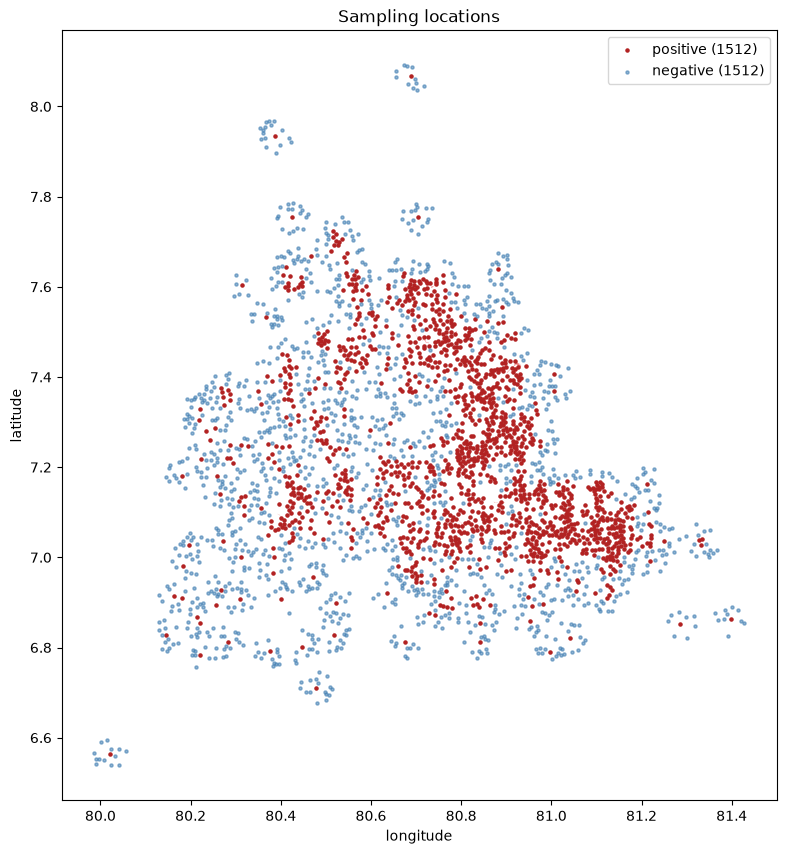

In [58]:
fig, ax = plt.subplots(figsize=(10, 10))
polys.to_crs("EPSG:4326").plot(ax=ax, color="lightcoral", markersize=1)
ax.scatter(pos_lab.longitude, pos_lab.latitude, s=5, c="firebrick",
           label=f"positive ({len(pos_lab)})")
ax.scatter(neg_lab.longitude, neg_lab.latitude, s=5, c="steelblue",
           alpha=.6, label=f"negative ({len(neg_lab)})")
ax.set(title="Sampling locations", xlabel="longitude", ylabel="latitude")
ax.legend(); ax.set_aspect("equal")
plt.savefig(FIG_DIR / "04_sampling_map.png", dpi=130, bbox_inches="tight")
plt.show()

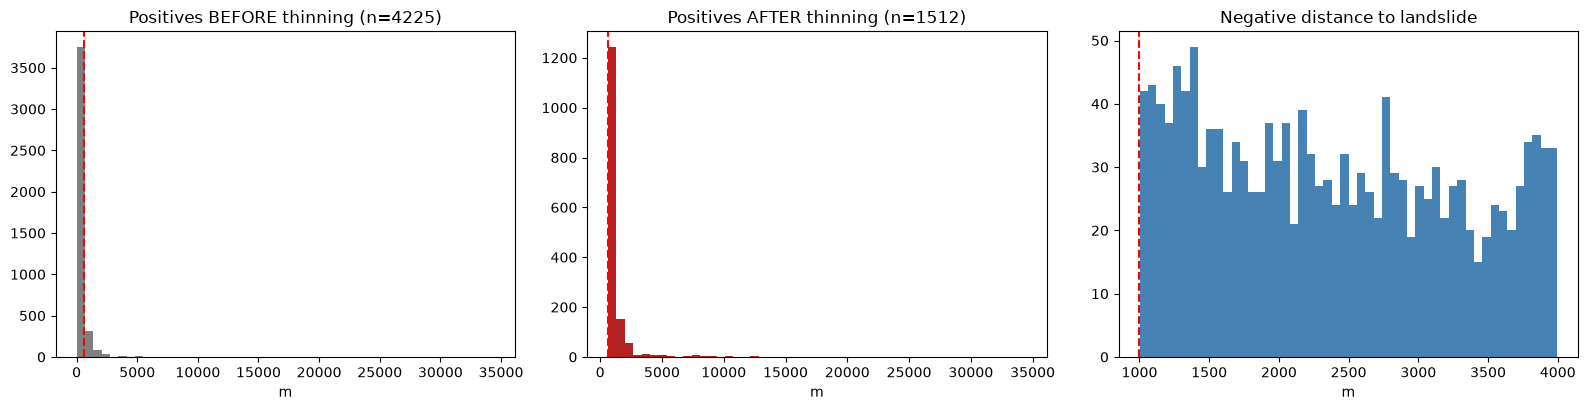

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].hist(nn, bins=50, color="grey")
ax[0].axvline(MIN_SEPARATION, color="red", ls="--")
ax[0].set(title=f"Positives BEFORE thinning (n={len(pos_raw)})", xlabel="m")

ax[1].hist(nn_after, bins=50, color="firebrick")
ax[1].axvline(MIN_SEPARATION, color="red", ls="--")
ax[1].set(title=f"Positives AFTER thinning (n={len(pos)})", xlabel="m")

ax[2].hist(d_slide, bins=50, color="steelblue")
ax[2].axvline(MIN_DIST_M, color="red", ls="--")
ax[2].set(title="Negative distance to landslide", xlabel="m")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_separation.png", dpi=130, bbox_inches="tight")
plt.show()